In [1]:
import astroquery
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

In [2]:
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source" #remove table size warnings


In [3]:
#Query data
query = """
SELECT TOP 2000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE parallax > 0 
AND parallax_over_error > 10
"""
job = Gaia.launch_job_async(query) #Launch Query
results = job.get_results() #Get results in astropy table
results.pprint(max_width=-1) #disply first few results

INFO: Query finished. [astroquery.utils.tap.core]
   source_id            ra                 dec              parallax              pmra                pmdec        phot_g_mean_mag   bp_rp    parallax_over_error    ruwe    phot_bp_rp_excess_factor
                       deg                 deg                mas               mas / yr             mas / yr            mag          mag                                                            
--------------- ------------------ ------------------- ------------------ -------------------- ------------------- --------------- ---------- ------------------- ---------- ------------------------
  7632157690368 45.034342834696204 0.23538959951604121   5.60229354383997     45.4660098305345  -6.834343096515991        8.068802  1.1340799           176.03023  1.3809834                1.2289604
 12545600306304 45.234476460376314  0.3181518585465403  4.329845546489255 0.056718525029955225  -48.33730294145812       12.194942  1.0196972           225.78

In [4]:
#Function to clean data (method adapted from Babusiaux 2018, changed to work with 3rd iteration of Gaia Data)
def clean_gaia_data(data_table):
    # boolean array (mask) that starts as all True
    mask = np.ones(len(data_table), dtype=bool)
    mask &= (data_table['parallax_over_error'] > 10) #This filter removes all data that has a parallax uncertainy > 10%
    # Babusiaux (2018) used 'astrometric_chi2_al' and 'excess_noise'.
    # In Data Release 3, these are combined into the RUWE score. An optimal RUWE is 1.0 however Bommert 2020 says anything <1.4 is acceptable
    mask &= (data_table['ruwe'] < 1.4)
    #Next remove stars where the brightness does not match the opbserved temp (happens w. binaries/overcrowded stars, etc.)
    #Babusiaux does this with a curve defined as Equation 1
    # removing outliers in 'phot_bp_rp_excess_factor' (found outside of 1.0-1.3 range) is effectively the same
    bp_rp = data_table['bp_rp']
    excess_factor = data_table['phot_bp_rp_excess_factor']
    #I created a simplified version of the curve from teh paper
    # 1.0 + 0.015*color^2  <  Factor  <  1.3 + 0.06*color^2
    lower_bound = 1.0 + 0.015 * bp_rp**2
    upper_bound = 1.3 + 0.06 * bp_rp**2
   
    mask &= (excess_factor > lower_bound) & (excess_factor < upper_bound)
    
    # Applying the mask
    cleaned_data = data_table[mask]
    
    print(f"Original rows: {len(data_table)}")
    print(f"Cleaned rows:  {len(cleaned_data)}")
    return cleaned_data

cleaned_results = clean_gaia_data(results)

Original rows: 2000
Cleaned rows:  1832


In [5]:
query = """
SELECT TOP 5000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 66.75, 15.87, 5))
AND parallax > 10  -- Optimization: Hyades is nearby (~45pc), so parallax must be large
"""

job = Gaia.launch_job_async(query)
hyades_raw = job.get_results()
hyades_clean = clean_gaia_data(hyades_raw)

INFO: Query finished. [astroquery.utils.tap.core]
Original rows: 953
Cleaned rows:  657


In [54]:
# Approximates the Babusiaux et al. iterative selection by sigma-clipping in Proper Motion and Parallax space.

def iterative_cluster_selection(data, sigma=3.0, max_iters=10):

    # boolean mask to track which stars are 'members'
    mask = np.ones(len(data), dtype=bool)
    
    # loop to refine selection
    for i in range(max_iters):
        # Selects the current working set of stars
        current_members = data[mask]
        
        # Calculates the center (median) and spread (std) of this set
        med_pmra = np.median(current_members['pmra'])
        std_pmra = np.std(current_members['pmra'])
        
        med_pmdec = np.median(current_members['pmdec'])
        std_pmdec = np.std(current_members['pmdec'])
        
        med_plx = np.median(current_members['parallax'])
        std_plx = np.std(current_members['parallax'])
        
        # new mask for the next iteration
        # A star is a member if it is within 'sigma' standard deviations 
        # of the center in ALL three coordinates.
        new_mask = (
            (np.abs(data['pmra'] - med_pmra) < sigma * std_pmra) &
            (np.abs(data['pmdec'] - med_pmdec) < sigma * std_pmdec) &
            (np.abs(data['parallax'] - med_plx) < sigma * std_plx)
        )
        
        # Once the mask no longer changes stop
        n_old = np.sum(mask)
        n_new = np.sum(new_mask)
        print(f"Iteration {i+1}: Kept {n_new} stars (was {n_old})")
        
        if np.array_equal(mask, new_mask):
            print("Converged!")
            break
            
        # Update the mask for the next loop
        mask = new_mask
        
    return data[mask]

hyades_members = iterative_cluster_selection(hyades_clean, sigma=2.5)

Iteration 1: Kept 622 stars (was 657)
Iteration 2: Kept 582 stars (was 622)
Iteration 3: Kept 545 stars (was 582)
Iteration 4: Kept 522 stars (was 545)
Iteration 5: Kept 503 stars (was 522)
Iteration 6: Kept 489 stars (was 503)
Iteration 7: Kept 476 stars (was 489)
Iteration 8: Kept 468 stars (was 476)
Iteration 9: Kept 458 stars (was 468)
Iteration 10: Kept 450 stars (was 458)


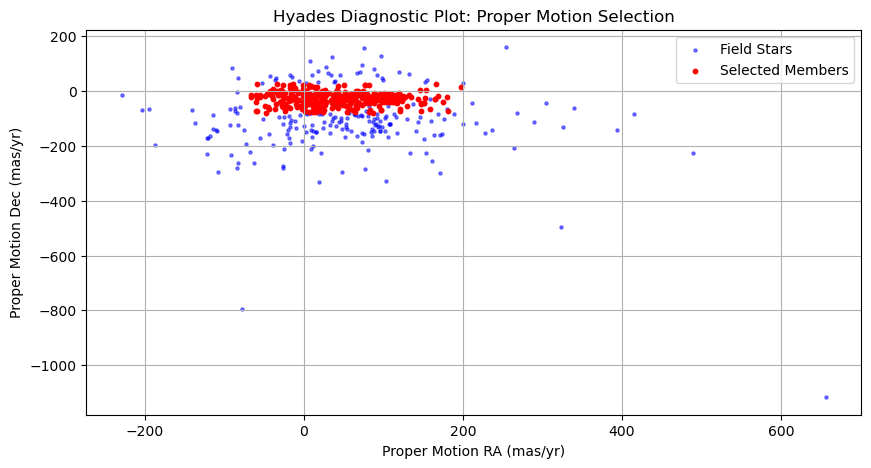

In [55]:
plt.figure(figsize=(10, 5))

# Plot all stars (Background)
plt.scatter(hyades_clean['pmra'], hyades_clean['pmdec'], 
            s=5, color='blue', alpha=0.5, label='Field Stars')

# Plot selected members (Cluster)
plt.scatter(hyades_members['pmra'], hyades_members['pmdec'], 
            s=10, color='red', label='Selected Members')

plt.xlabel('Proper Motion RA (mas/yr)')
plt.ylabel('Proper Motion Dec (mas/yr)')
plt.title('Hyades Diagnostic Plot: Proper Motion Selection')
plt.legend()
plt.grid(True)
plt.show()

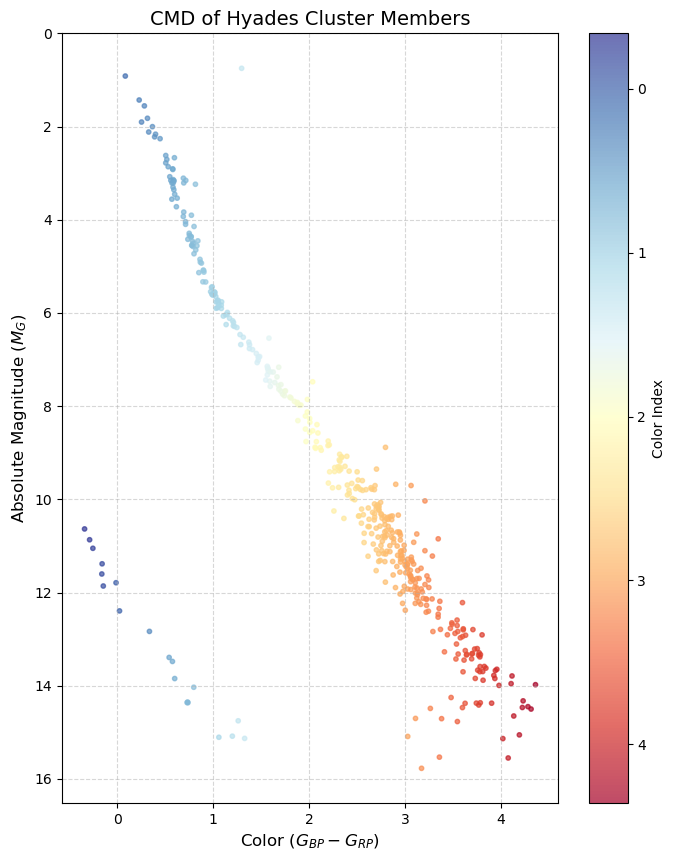

In [56]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / hyades_members['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = hyades_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = hyades_members['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Hyades Cluster Members', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

In [9]:
# M67 Query
# Center: RA 132.83, Dec 11.82
# Radius: 1.0 degree siucne the cluster is more compact than Hyaedes
query_m67 = """
SELECT TOP 5000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 132.83, 11.82, 1.0))
AND parallax > 0.5  -- RELAXED CONSTRAINT: M67 is distant (~1.1 mas)
"""

job_m67 = Gaia.launch_job_async(query_m67)
m67_raw = job_m67.get_results()
m67_clean = clean_gaia_data(m67_raw)

INFO: Query finished. [astroquery.utils.tap.core]
Original rows: 5000
Cleaned rows:  1681


In [58]:
m67_members = iterative_cluster_selection(m67_clean, sigma=2.0)

print(f"Median Parallax: {np.median(m67_members['parallax']):.2f} mas")

Iteration 1: Kept 1523 stars (was 1681)
Iteration 2: Kept 1268 stars (was 1523)
Iteration 3: Kept 1057 stars (was 1268)
Iteration 4: Kept 898 stars (was 1057)
Iteration 5: Kept 765 stars (was 898)
Iteration 6: Kept 608 stars (was 765)
Iteration 7: Kept 446 stars (was 608)
Iteration 8: Kept 344 stars (was 446)
Iteration 9: Kept 302 stars (was 344)
Iteration 10: Kept 265 stars (was 302)
Median Parallax: 1.15 mas


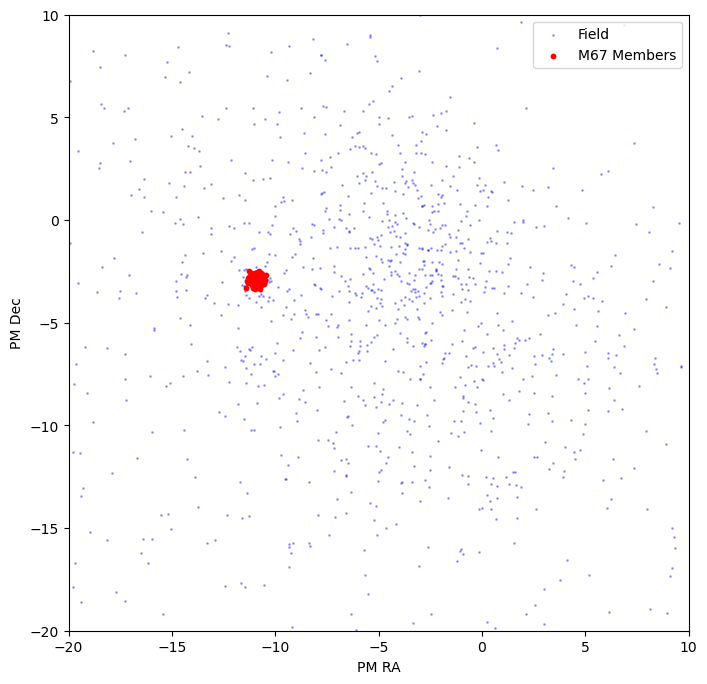

In [59]:
plt.figure(figsize=(8, 8))
plt.scatter(m67_clean['pmra'], m67_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
plt.scatter(m67_members['pmra'], m67_members['pmdec'], s=10, color='red', label='M67 Members')
plt.xlim(-20, 10) # Zoom in! M67 motion is small.
plt.ylim(-20, 10)
plt.xlabel('PM RA')
plt.ylabel('PM Dec')
plt.legend()
plt.show()

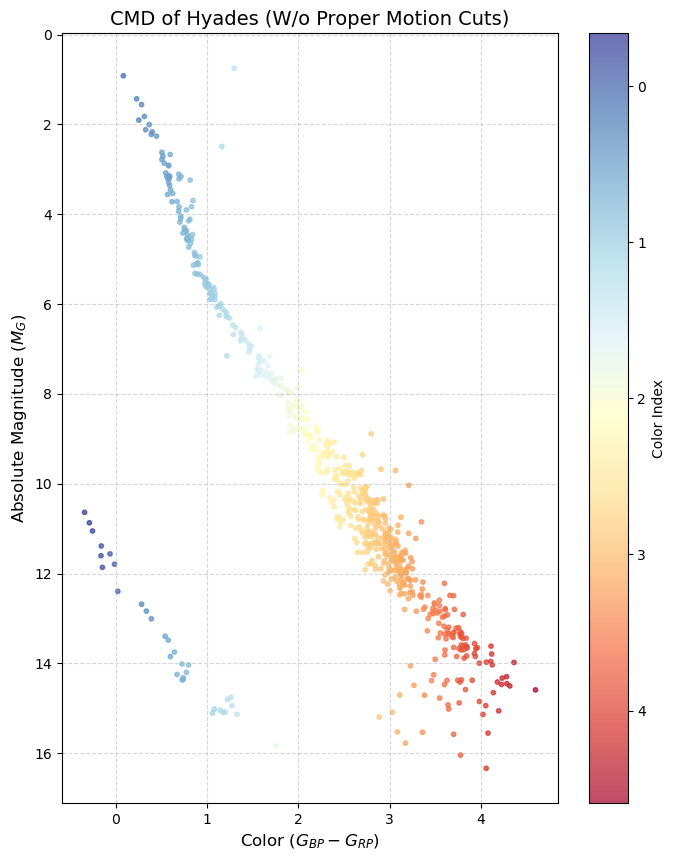

In [12]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / hyades_clean['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = hyades_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = hyades_clean['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Hyades (W/o Proper Motion Cuts)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

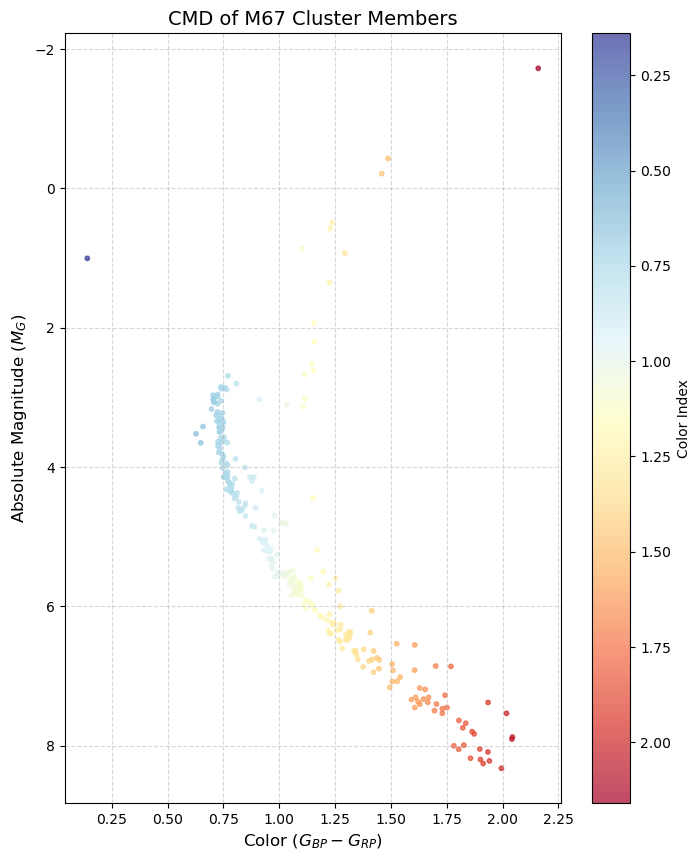

In [60]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / m67_members['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = m67_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = m67_members['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of M67 Cluster Members', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

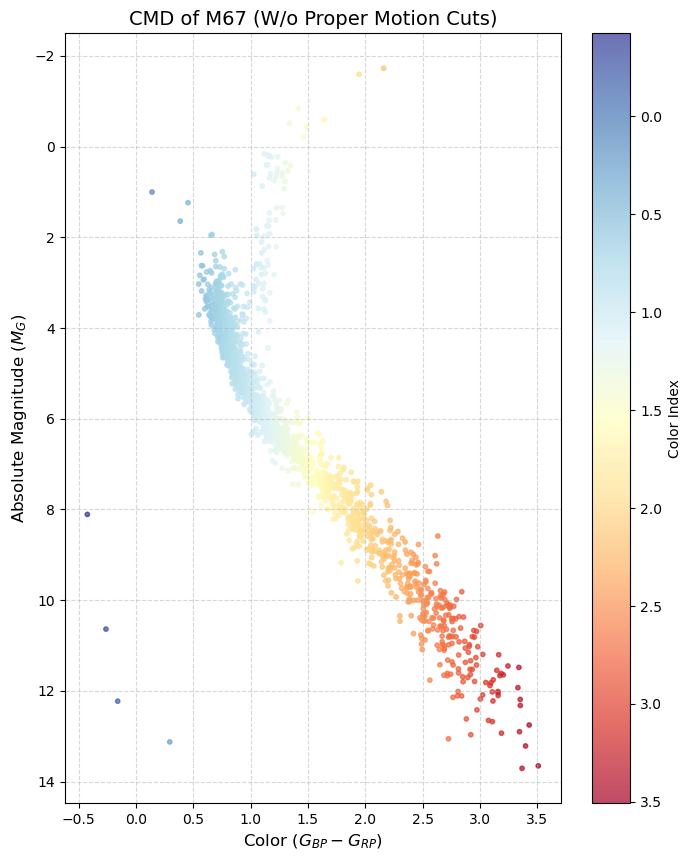

In [14]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / m67_clean['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = m67_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = m67_clean['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of M67 (W/o Proper Motion Cuts)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

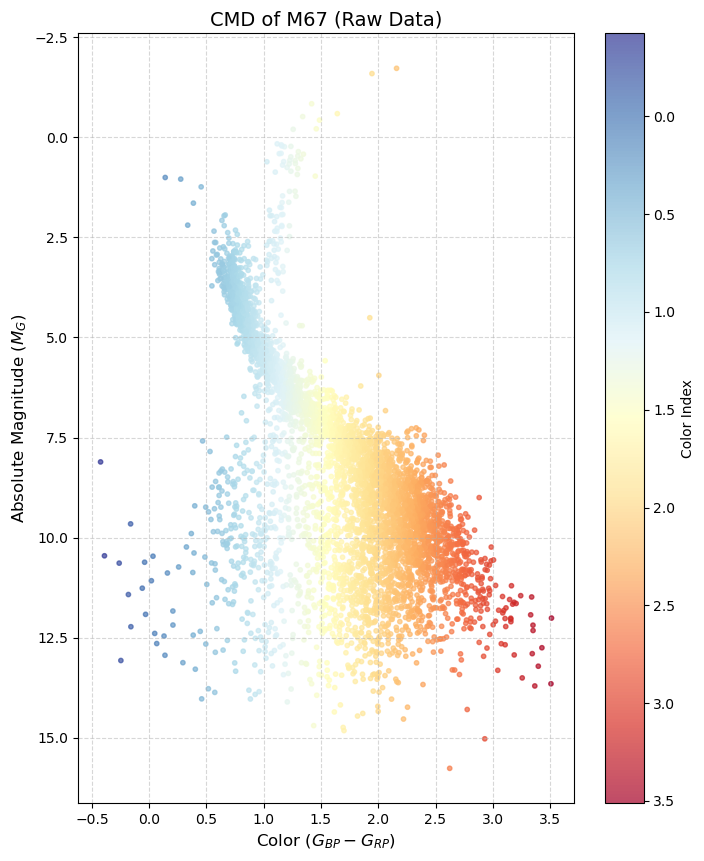

In [15]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / m67_raw['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = m67_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = m67_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of M67 (Raw Data)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

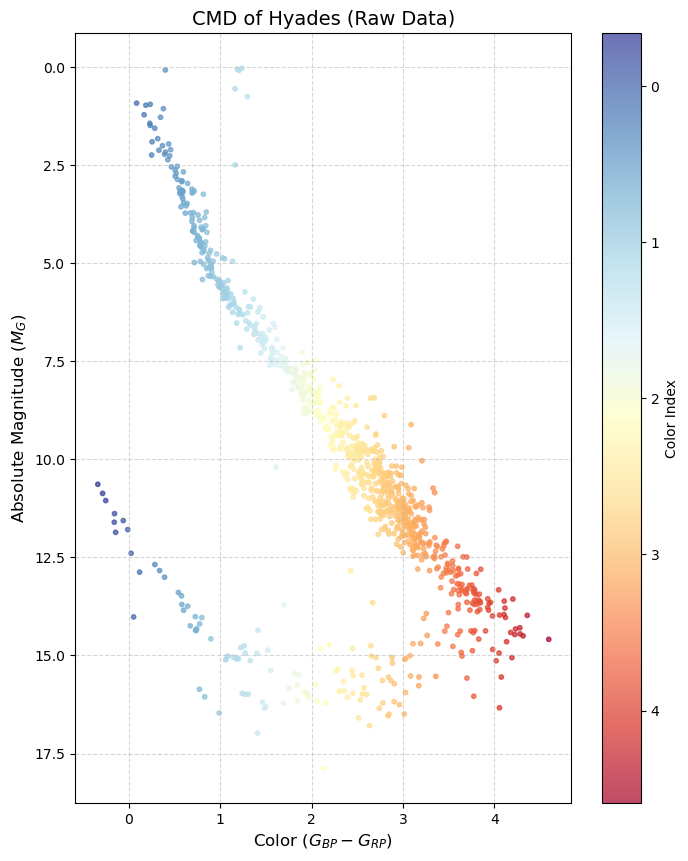

In [16]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / hyades_raw['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = hyades_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = hyades_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Hyades (Raw Data)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

In [17]:
def clean_gaia_data(data_table):
    """Applies basic quality cuts (RUWE, Parallax Precision, Excess Factor)"""
    # Relaxed parallax cut for distant globular clusters (error < 20%)
    mask = (data_table['parallax_over_error'] > 5) 
    mask &= (data_table['ruwe'] < 1.4)
    
    # Color consistency cut
    bp_rp = data_table['bp_rp']
    excess = data_table['phot_bp_rp_excess_factor']
    lower_curve = 1.0 + 0.015 * bp_rp**2
    upper_curve = 1.3 + 0.06 * bp_rp**2
    mask &= (excess > lower_curve) & (excess < upper_curve)
    
    return data_table[mask]

def iterative_cluster_selection(data, sigma=3.0, max_iters=10):
    """Selects members by iteratively clipping outliers in PM and Parallax"""
    mask = np.ones(len(data), dtype=bool)
    for i in range(max_iters):
        current = data[mask]
        if len(current) < 10: break # Safety stop
        
        med_pmra, std_pmra = np.median(current['pmra']), np.std(current['pmra'])
        med_pmdec, std_pmdec = np.median(current['pmdec']), np.std(current['pmdec'])
        med_plx, std_plx = np.median(current['parallax']), np.std(current['parallax'])
        
        new_mask = (
            (np.abs(data['pmra'] - med_pmra) < sigma * std_pmra) &
            (np.abs(data['pmdec'] - med_pmdec) < sigma * std_pmdec) &
            (np.abs(data['parallax'] - med_plx) < sigma * std_plx)
        )
        if np.array_equal(mask, new_mask): break
        mask = new_mask
    return data[mask]

In [18]:
print("Fetching NGC 6397 data...")
# Coordinates: RA ~ 265.17, Dec ~ -53.67
# Parallax is small (~0.4 mas), so we lower the strict lower bound to 0.1
query_ngc = """
SELECT TOP 5000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 265.175, -53.674, 0.5))
AND parallax > 0.1 
"""

job_ngc = Gaia.launch_job_async(query_ngc)
ngc_raw = job_ngc.get_results()

# Apply quality cleaning
ngc_clean = clean_gaia_data(ngc_raw)
print(f"Rows after basic cleaning: {len(ngc_clean)}")

Fetching NGC 6397 data...
INFO: Query finished. [astroquery.utils.tap.core]
Rows after basic cleaning: 728


In [19]:
# --- 3. SELECTION (THE CUT) ---
# We use sigma=3.0. Globular clusters have high internal velocity dispersion,
# so if you cut too tight (sigma=2.0), you might slice off real members.
ngc_members = iterative_cluster_selection(ngc_clean, sigma=2.0)
print(f"Final Members Selected: {len(ngc_members)}")

Final Members Selected: 298


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


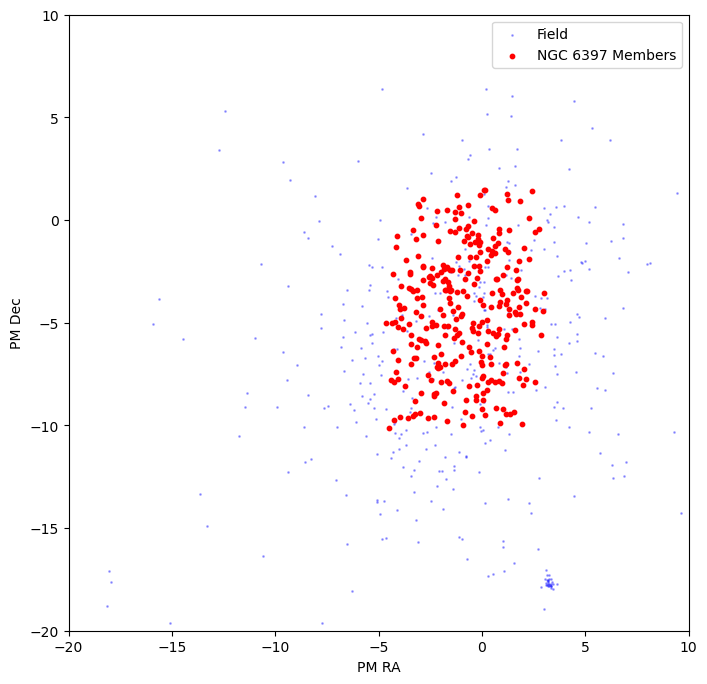

In [20]:
plt.figure(figsize=(8, 8))
plt.scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
plt.scatter(ngc_members['pmra'], ngc_members['pmdec'], s=10, color='red', label='NGC 6397 Members')
plt.xlim(-20, 10) 
plt.ylim(-20, 10)
plt.xlabel('PM RA')
plt.ylabel('PM Dec')
plt.legend()
plt.show()

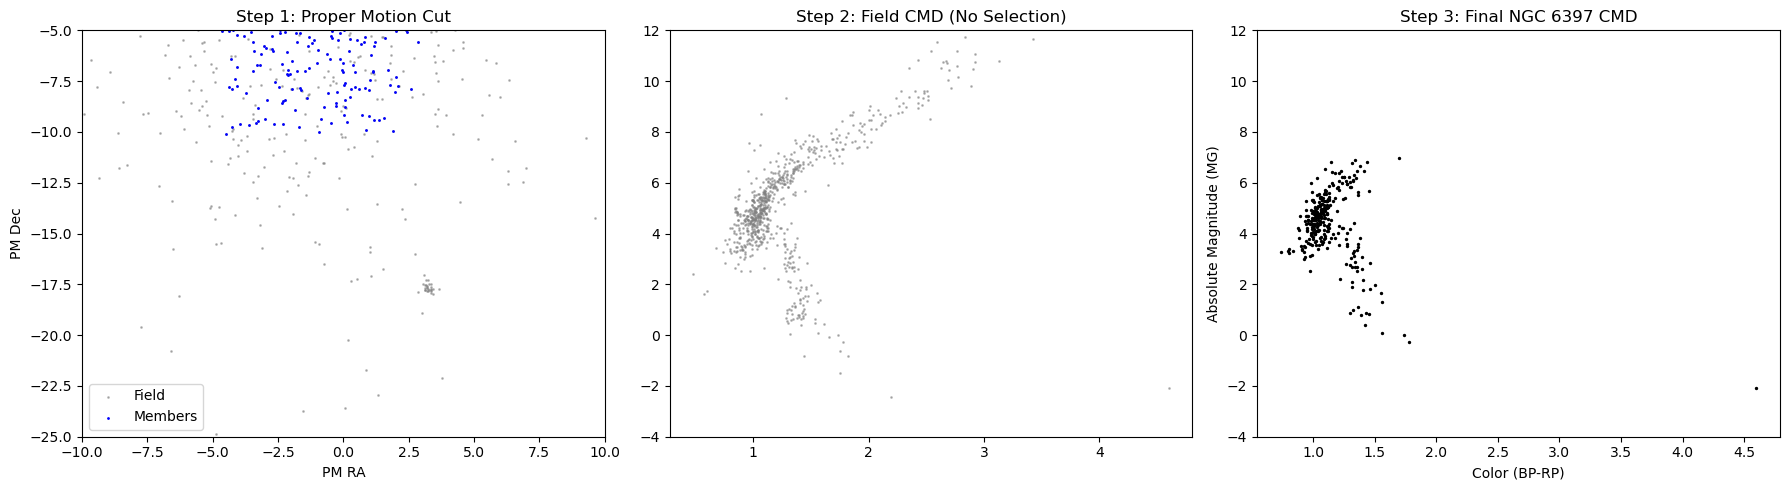

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Proper Motion Selection
axes[0].scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, c='gray', alpha=0.5, label='Field')
axes[0].scatter(ngc_members['pmra'], ngc_members['pmdec'], s=1, c='blue', label='Members')
axes[0].set_xlim(-10, 10) # Zoom in to see the separation
axes[0].set_ylim(-25, -5)
axes[0].set_xlabel('PM RA')
axes[0].set_ylabel('PM Dec')
axes[0].set_title('Step 1: Proper Motion Cut')
axes[0].legend()

# Plot B: Field CMD (Messy)
dist_field = 1000.0 / np.maximum(ngc_clean['parallax'], 0.01) # Avoid divide by zero
mg_field = ngc_clean['phot_g_mean_mag'] - 5 * np.log10(dist_field) + 5
axes[1].scatter(ngc_clean['bp_rp'], mg_field, s=1, c='gray', alpha=0.5)
axes[1].set_ylim(12, -4)
axes[1].invert_yaxis()
axes[1].set_title('Step 2: Field CMD (No Selection)')

# Plot C: Final Cluster CMD (Clean)
dist_mem = 1000.0 / ngc_members['parallax']
mg_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(dist_mem) + 5
axes[2].scatter(ngc_members['bp_rp'], mg_mem, s=2, c='black')
axes[2].set_ylim(12, -4)
axes[2].invert_yaxis()
axes[2].set_title('Step 3: Final NGC 6397 CMD')
axes[2].set_xlabel('Color (BP-RP)')
axes[2].set_ylabel('Absolute Magnitude (MG)')

plt.tight_layout()
plt.show()

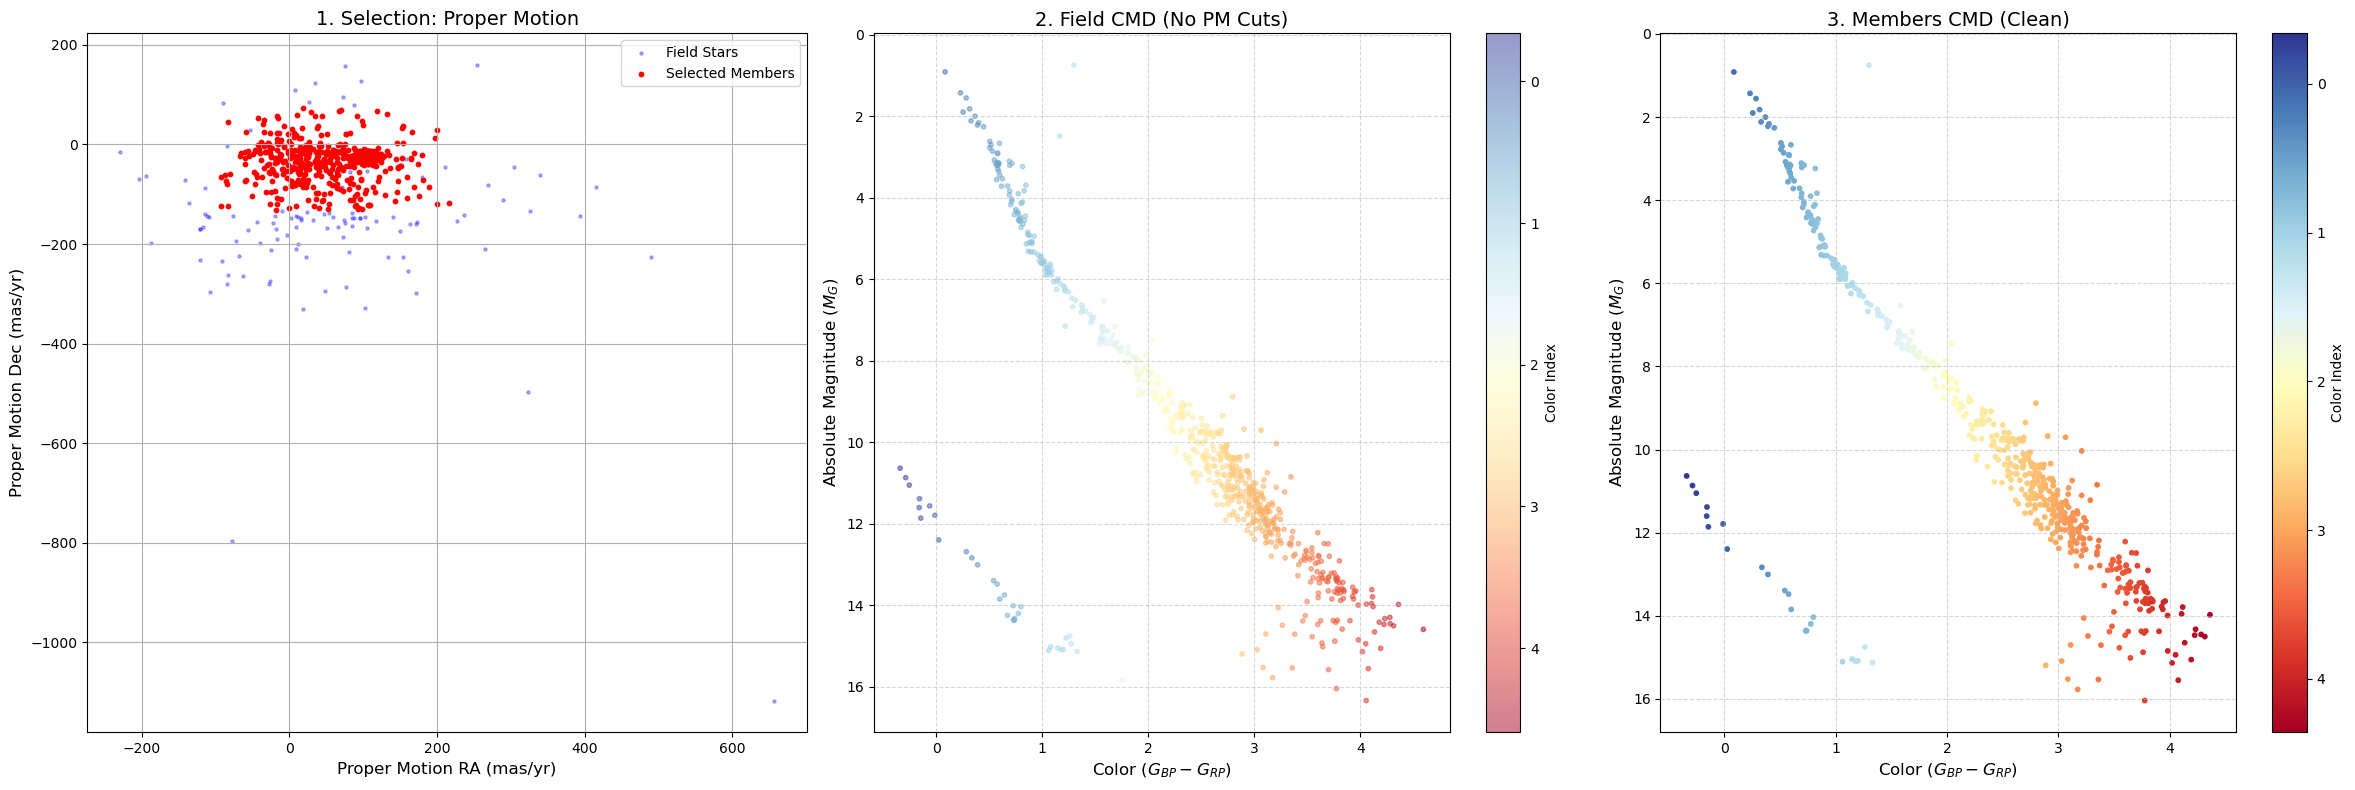

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# ==========================================
# PLOT 1: Diagnostic Plot (Proper Motion)
# ==========================================
# We map this to axes[0] (the first plot on the left)
axes[0].scatter(hyades_clean['pmra'], hyades_clean['pmdec'], 
                s=5, color='blue', alpha=0.3, label='Field Stars')

axes[0].scatter(hyades_members['pmra'], hyades_members['pmdec'], 
                s=10, color='red', label='Selected Members')

axes[0].set_xlabel('Proper Motion RA (mas/yr)', fontsize=12)
axes[0].set_ylabel('Proper Motion Dec (mas/yr)', fontsize=12)
axes[0].set_title('1. Selection: Proper Motion', fontsize=14)
axes[0].legend()
axes[0].grid(True)


# ==========================================
# PLOT 2: HR Diagram (Before Cuts)
# ==========================================
# We map this to axes[1] (the middle plot)

# Recalculate physics for the "Clean/Field" set
dist_field = 1000.0 / hyades_clean['parallax']
abs_mag_field = hyades_clean['phot_g_mean_mag'] - 5 * np.log10(dist_field) + 5
color_field = hyades_clean['bp_rp']

# Plotting
sc1 = axes[1].scatter(color_field, abs_mag_field, s=10, c=color_field, cmap='RdYlBu_r', alpha=0.5)

axes[1].invert_yaxis() # Standard astronomy convention
axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[1].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[1].set_title('2. Field CMD (No PM Cuts)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Add colorbar specifically for this subplot
cb1 = plt.colorbar(sc1, ax=axes[1], label='Color Index')
cb1.ax.invert_yaxis()


# ==========================================
# PLOT 3: HR Diagram (After Cuts)
# ==========================================
# We map this to axes[2] (the right plot)

# Recalculate physics for the "Members" set
dist_mem = 1000.0 / hyades_members['parallax']
abs_mag_mem = hyades_members['phot_g_mean_mag'] - 5 * np.log10(dist_mem) + 5
color_mem = hyades_members['bp_rp']

# Plotting
sc2 = axes[2].scatter(color_mem, abs_mag_mem, s=10, c=color_mem, cmap='RdYlBu_r', alpha=1.0)

axes[2].invert_yaxis()
axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[2].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[2].set_title('3. Members CMD (Clean)', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# Add colorbar specifically for this subplot
cb2 = plt.colorbar(sc2, ax=axes[2], label='Color Index')
cb2.ax.invert_yaxis()

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cluster_panel(field_data, member_data, cluster_name, pm_lims=None, mag_lims=None):
    """
    Generates a 3-panel diagnostic plot for a cluster.
    
    Parameters:
    - field_data: The 'raw' data table (after quality clean, before PM selection)
    - member_data: The 'selected' data table (after PM selection)
    - cluster_name: String for titles (e.g., "M67")
    - pm_lims: Tuple of ((x_min, x_max), (y_min, y_max)) for PM plot
    - mag_lims: Tuple (y_max, y_min) for CMD Y-axis (Note: brighter is smaller number)
    """
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    
    # --- HELPER: Calculate Abs Mag Safely ---
    def get_abs_mag(t):
        # Prevent divide-by-zero or log of negative for field stars
        # We clip parallax to a tiny positive number just for plotting math
        d = 1000.0 / np.maximum(t['parallax'], 0.001) 
        return t['phot_g_mean_mag'] - 5 * np.log10(d) + 5

    # ==========================================
    # PLOT 1: Diagnostic Plot (Proper Motion)
    # ==========================================
    axes[0].scatter(field_data['pmra'], field_data['pmdec'], 
                    s=5, color='gray', alpha=0.4, label='Field Stars')
    axes[0].scatter(member_data['pmra'], member_data['pmdec'], 
                    s=10, color='blue', label='Members')
    
    axes[0].set_xlabel('PM RA (mas/yr)', fontsize=12)
    axes[0].set_ylabel('PM Dec (mas/yr)', fontsize=12)
    axes[0].set_title(f'{cluster_name}: PM Selection', fontsize=14)
    axes[0].legend()
    axes[0].grid(True)
    
    if pm_lims:
        axes[0].set_xlim(pm_lims[0])
        axes[0].set_ylim(pm_lims[1])

    # ==========================================
    # PLOT 2: Field CMD (Before Cuts)
    # ==========================================
    mg_field = get_abs_mag(field_data)
    axes[1].scatter(field_data['bp_rp'], mg_field, 
                    s=5, c='gray', alpha=0.4)
    
    axes[1].set_title(f'{cluster_name}: Field CMD', fontsize=14)
    axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
    axes[1].set_ylabel('Abs Mag ($M_G$)', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].invert_yaxis()
    
    if mag_lims:
        axes[1].set_ylim(mag_lims[0], mag_lims[1])

    # ==========================================
    # PLOT 3: Members CMD (After Cuts)
    # ==========================================
    mg_mem = get_abs_mag(member_data)
    sc = axes[2].scatter(member_data['bp_rp'], mg_mem, 
                         s=10, c=member_data['bp_rp'], cmap='RdYlBu_r', alpha=1.0)
    
    axes[2].set_title(f'{cluster_name}: Members CMD', fontsize=14)
    axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
    axes[2].set_ylabel('Abs Mag ($M_G$)', fontsize=12)
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].invert_yaxis()
    
    if mag_lims:
        axes[2].set_ylim(mag_lims[0], mag_lims[1])

    # Colorbar
    cb = plt.colorbar(sc, ax=axes[2], label='Color Index')
    cb.ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

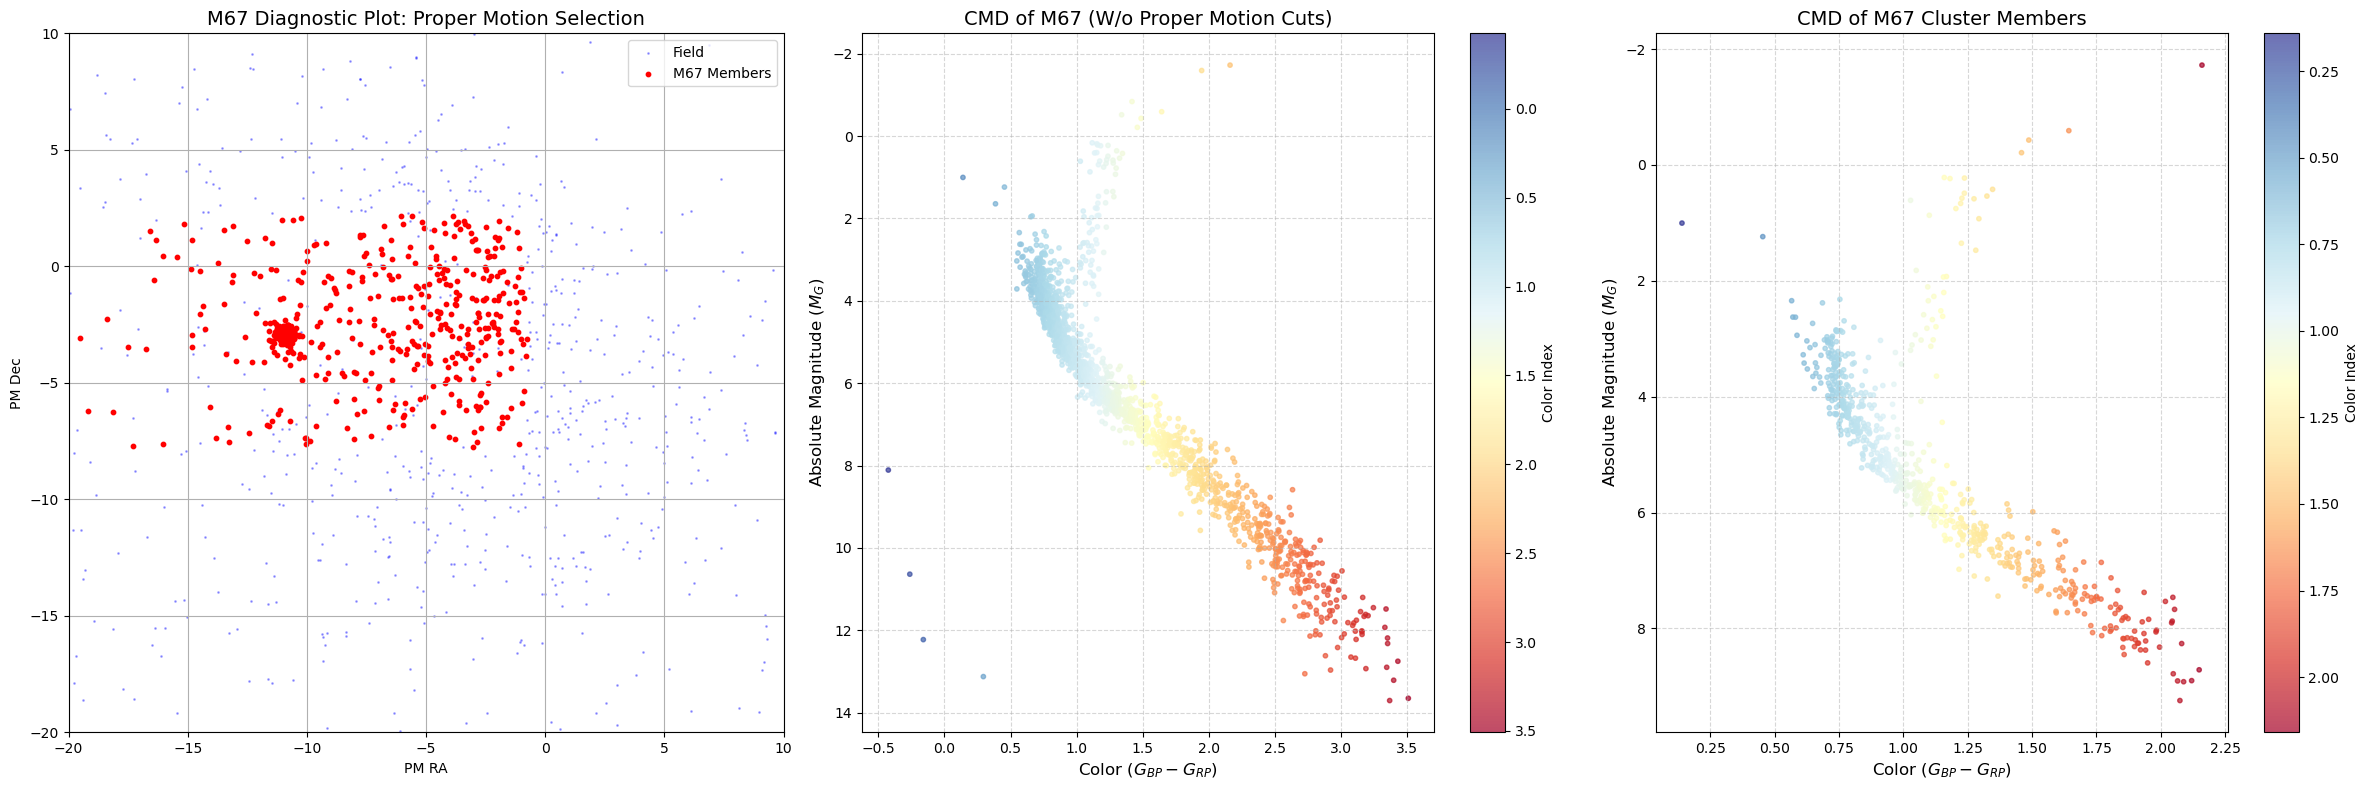

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# ==========================================
# PLOT 1: M67 Diagnostic Plot (Proper Motion)
# ==========================================
# Mapped to axes[0]
axes[0].scatter(m67_clean['pmra'], m67_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
axes[0].scatter(m67_members['pmra'], m67_members['pmdec'], s=10, color='red', label='M67 Members')

# Your specific limits and labels
axes[0].set_xlim(-20, 10) 
axes[0].set_ylim(-20, 10)
axes[0].set_xlabel('PM RA')
axes[0].set_ylabel('PM Dec')
axes[0].set_title('M67 Diagnostic Plot: Proper Motion Selection', fontsize=14)
axes[0].legend()
axes[0].grid(True)


# ==========================================
# PLOT 2: M67 CMD (Without Proper Motion Cuts)
# ==========================================
# Mapped to axes[1]

# Calculations using m67_clean
distance_pc_field = 1000.0 / m67_clean['parallax']
abs_mag_field = m67_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc_field) + 5
color_field = m67_clean['bp_rp']

# Plotting
sc1 = axes[1].scatter(color_field, abs_mag_field, s=10, c=color_field, cmap='RdYlBu_r', alpha=0.7)

# Formatting
axes[1].invert_yaxis()
axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[1].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[1].set_title('CMD of M67 (W/o Proper Motion Cuts)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb1 = plt.colorbar(sc1, ax=axes[1], label='Color Index')
cb1.ax.invert_yaxis()


# ==========================================
# PLOT 3: M67 CMD (With Proper Motion Cuts)
# ==========================================
# Mapped to axes[2]

# Calculations using m67_members
distance_pc_mem = 1000.0 / m67_members['parallax']
abs_mag_mem = m67_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = m67_members['bp_rp']

# Plotting
sc2 = axes[2].scatter(color_mem, abs_mag_mem, s=10, c=color_mem, cmap='RdYlBu_r', alpha=0.7)

# Formatting
axes[2].invert_yaxis()
axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[2].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[2].set_title('CMD of M67 Cluster Members', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb2 = plt.colorbar(sc2, ax=axes[2], label='Color Index')
cb2.ax.invert_yaxis()

# Final layout adjustment
plt.tight_layout()
plt.show()

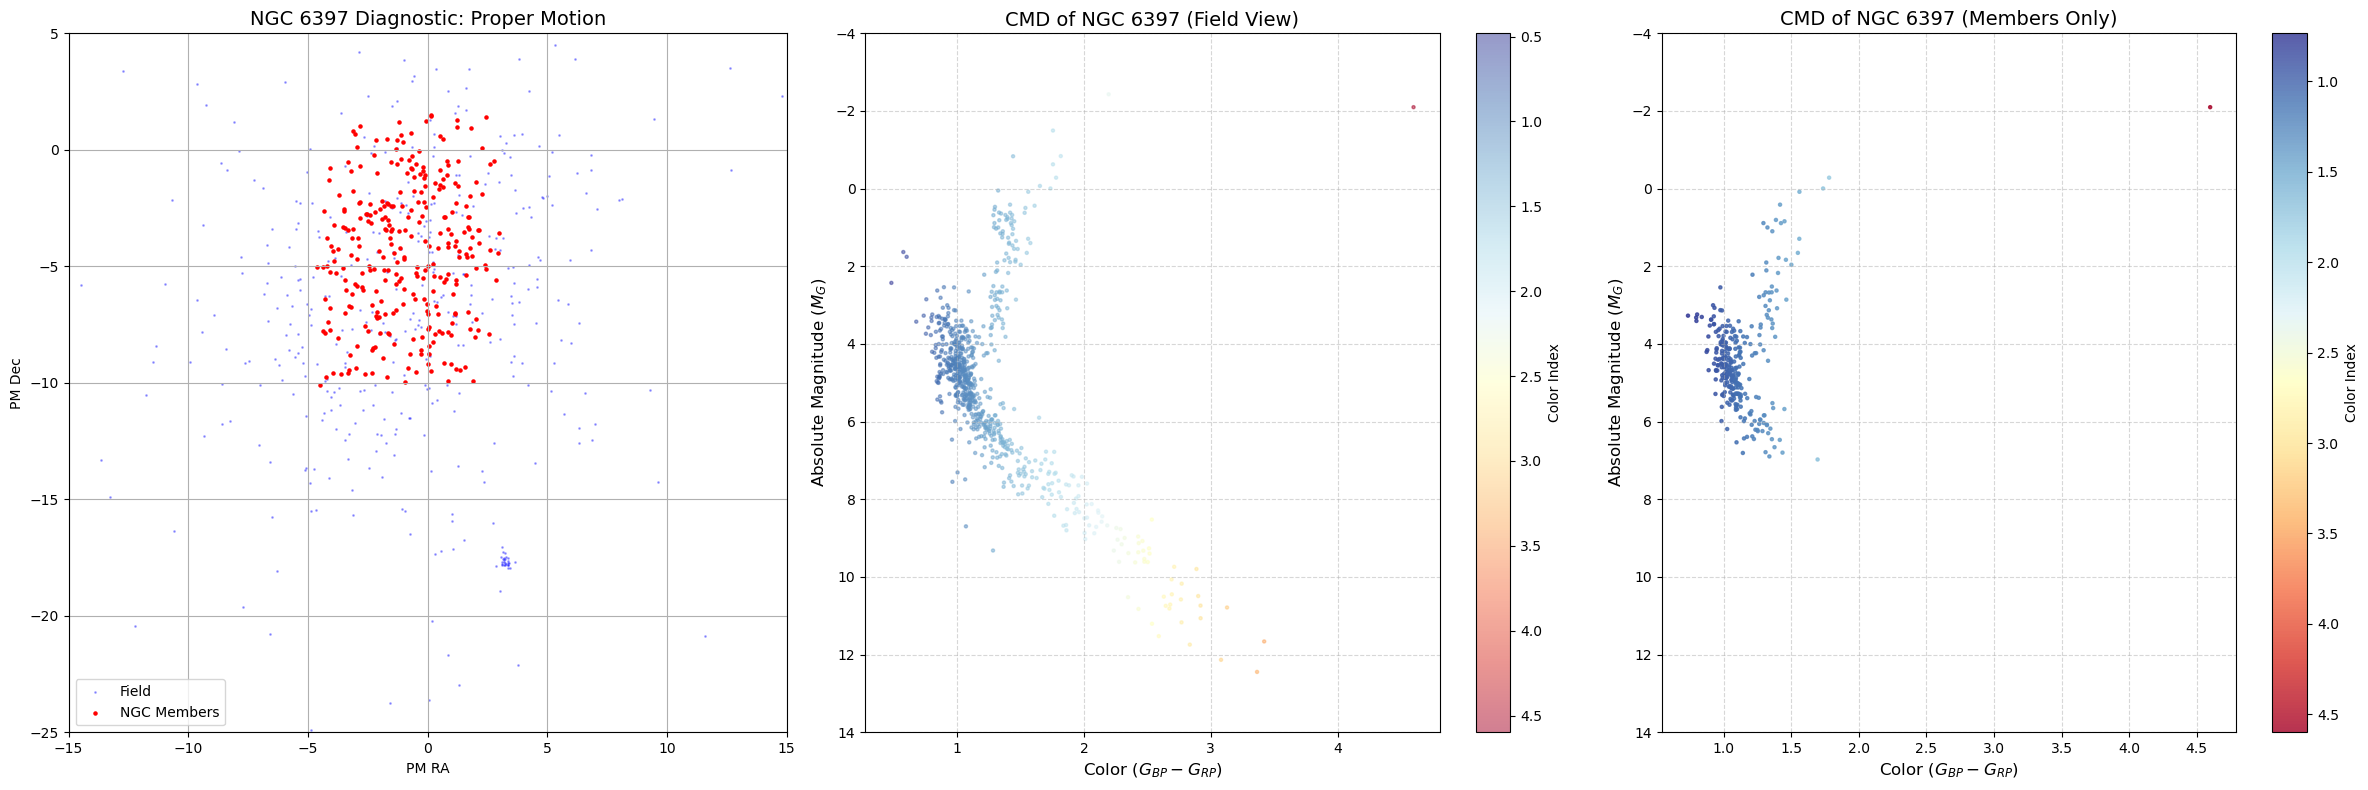

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# ==========================================
# PLOT 1: NGC 6397 Diagnostic Plot (Proper Motion)
# ==========================================
# Mapped to axes[0]
axes[0].scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
axes[0].scatter(ngc_members['pmra'], ngc_members['pmdec'], s=5, color='red', label='NGC Members')

# Limits adjusted for NGC 6397 (High Proper Motion)
axes[0].set_xlim(-15, 15) 
axes[0].set_ylim(-25, 5)
axes[0].set_xlabel('PM RA')
axes[0].set_ylabel('PM Dec')
axes[0].set_title('NGC 6397 Diagnostic: Proper Motion', fontsize=14)
axes[0].legend()
axes[0].grid(True)


# ==========================================
# PLOT 2: NGC 6397 CMD (Without Proper Motion Cuts)
# ==========================================
# Mapped to axes[1]

# Safety: Ensure we don't divide by zero/negative parallax for background stars
# We clip parallax to a minimum of 0.01 mas (very distant)
distance_pc_field = 1000.0 / np.maximum(ngc_clean['parallax'], 0.01)
abs_mag_field = ngc_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc_field) + 5
color_field = ngc_clean['bp_rp']

# Plotting
sc1 = axes[1].scatter(color_field, abs_mag_field, s=5, c=color_field, cmap='RdYlBu_r', alpha=0.5)

# Formatting
axes[1].invert_yaxis()
axes[1].set_ylim(14, -4) # Deep limit for Globular Cluster
axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[1].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[1].set_title('CMD of NGC 6397 (Field View)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb1 = plt.colorbar(sc1, ax=axes[1], label='Color Index')
cb1.ax.invert_yaxis()


# ==========================================
# PLOT 3: NGC 6397 CMD (With Proper Motion Cuts)
# ==========================================
# Mapped to axes[2]

# Calculations using ngc_members
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

# Plotting
sc2 = axes[2].scatter(color_mem, abs_mag_mem, s=5, c=color_mem, cmap='RdYlBu_r', alpha=0.8)

# Formatting
axes[2].invert_yaxis()
axes[2].set_ylim(14, -4) # Consistent limits
axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[2].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[2].set_title('CMD of NGC 6397 (Members Only)', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb2 = plt.colorbar(sc2, ax=axes[2], label='Color Index')
cb2.ax.invert_yaxis()

# Final layout adjustment
plt.tight_layout()
plt.show()

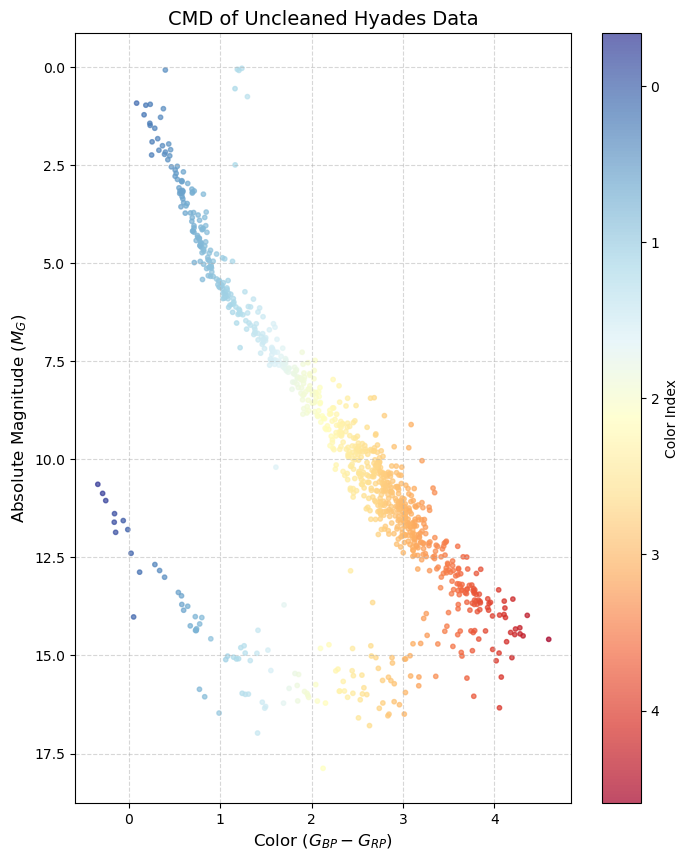

In [26]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / hyades_raw['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = hyades_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = hyades_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Uncleaned Hyades Data', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

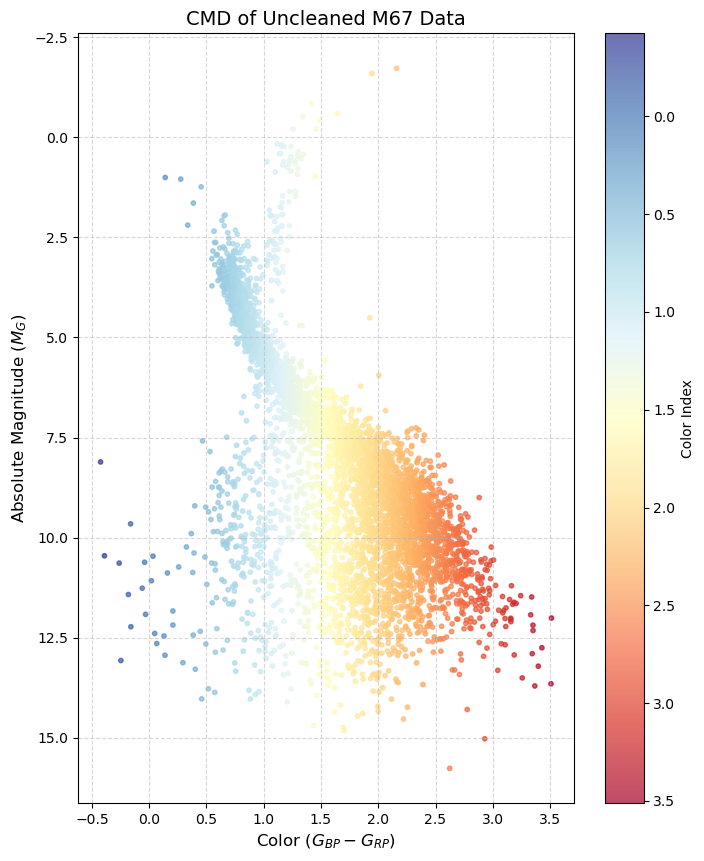

In [27]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / m67_raw['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = m67_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = m67_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Uncleaned M67 Data', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

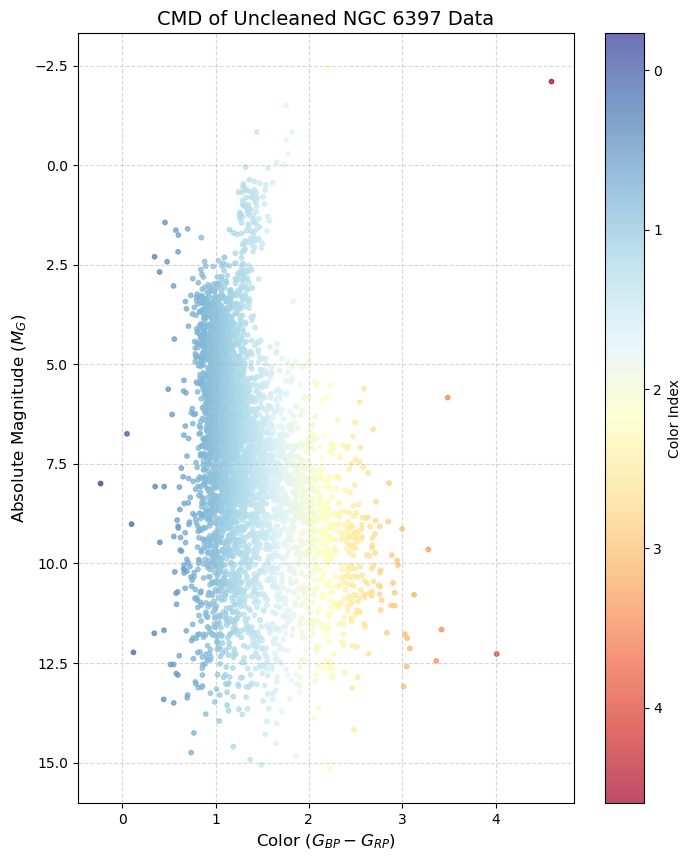

In [28]:
# Calculate Distance 
# Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / ngc_raw['parallax']

# Calculate Absolute Magnitude (Mg)
# M = m - 5 * log10(d) + 5
abs_mag_g = ngc_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Define Color
# Gaia provides 'bp_rp' directly, which is (Blue_mag - Red_mag)
color = ngc_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

# inverting y axis b/c HR diagram
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Uncleaned NGC 6397 Data', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
cb = plt.colorbar(label='Color Index')
cb.ax.invert_yaxis() 

plt.show()

In [29]:
def read_mist_isochrones(filename):
    """
    Reads a MIST .cmd file and returns a dictionary of isochrones.
    Structure: isochrones[feh][log_age] = table_of_data
    """
    isochrones = {}
    
    # Open the file to parse headers and data
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the column names (usually the last line starting with # before data)
    # MIST files typically have header lines starting with '#'
    col_names = []
    data_start = 0
    
    for i, line in enumerate(lines):
        if line.startswith('#'):
            # The last commented line usually contains column headers
            if not lines[i+1].startswith('#'):
                col_names = line.strip().lstrip('#').split()
                data_start = i + 1
                break
    
    print(f"Detected {len(col_names)} columns: {col_names[:5]} ...")
    
    # Load the numerical data
    # We use pandas if available for speed, otherwise numpy
    try:
        import pandas as pd
        # Read file, skipping header rows
        df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)
        
        # Group by Metallicity and Age
        # MIST column names are usually 'log10_isochrone_age_yr' and '[Fe/H]_init'
        # Check your specific file if keys error out
        age_col = [c for c in df.columns if 'age' in c and 'yr' in c][0]
        feh_col = [c for c in df.columns if 'Fe/H' in c][0]
        
        # Create the dictionary structure
        unique_feh = df[feh_col].unique()
        for feh in unique_feh:
            isochrones[feh] = {}
            feh_group = df[df[feh_col] == feh]
            unique_ages = feh_group[age_col].unique()
            
            for age in unique_ages:
                isochrones[feh][age] = feh_group[feh_group[age_col] == age]
                
    except ImportError:
        print("Pandas not found, using slower numpy parsing...")
        # (Fallback code omitted for brevity; highly recommend using pandas)
        return None

    print(f"Loaded isochrones for [Fe/H]: {list(isochrones.keys())}")
    return isochrones

# Usage:
# iso_data = read_mist_isochrones("MIST_ISOCHRONE_FILENAME.cmd")

In [30]:
iso_metallicity_pt25 = read_mist_isochrones("MIST_iso_697978eddda80.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_75020/3916338655.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(0.25)]


In [31]:
iso_metallicity_neg_pt5 = read_mist_isochrones("MIST_iso_697977f1c7c12.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_75020/3916338655.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(-0.5)]


In [32]:
iso_metallicity_neg_2 = read_mist_isochrones("MIST_iso_697977734f71f.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_75020/3916338655.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(-2.0)]


In [33]:
iso_metallicity_0 = read_mist_isochrones("MIST_iso_697978730525e.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_75020/3916338655.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(0.0)]


In [34]:
def plot_isochrone_overlay(ax, iso_data, target_feh, target_log_ages, dist_mod=0.0, extinction=0.0):
    """
    Overlays MIST isochrones on an existing matplotlib axis.
    
    Parameters:
    - ax: The matplotlib axis to plot on
    - iso_data: The dictionary returned by read_mist_isochrones
    - target_feh: The metallicity to plot (closest available will be chosen)
    - target_log_ages: A list of log10(ages) to plot (e.g., [8.8, 8.9])
    - dist_mod: Distance modulus (m - M). Use 0.0 if your data is already in Absolute Mag.
    - extinction: A_v or A_G estimate (optional simple shift)
    """
    # 1. Find closest available metallicity in the grid
    available_feh = np.array(list(iso_data.keys()))
    closest_feh = available_feh[np.abs(available_feh - target_feh).argmin()]
    
    print(f"Plotting models for [Fe/H] = {closest_feh} (Requested: {target_feh})")
    
    # 2. Loop through requested ages
    for log_age in target_log_ages:
        # Find closest available age
        available_ages = np.array(list(iso_data[closest_feh].keys()))
        closest_age = available_ages[np.abs(available_ages - log_age).argmin()]
        
        data = iso_data[closest_feh][closest_age]
        
        # 3. Extract Color and Mag
        # NOTE: Verify these column names match your MIST file header!
        try:
            # Common MIST names for Gaia EDR3
            G = data['Gaia_G_EDR3']
            BP = data['Gaia_BP_EDR3']
            RP = data['Gaia_RP_EDR3']
        except KeyError:
            # Fallback for generic names or DR2
            print("EDR3 columns not found, trying generic...")
            cols = data.columns
            G = data[[c for c in cols if 'Gaia_G' in c][0]]
            BP = data[[c for c in cols if 'Gaia_BP' in c][0]]
            RP = data[[c for c in cols if 'Gaia_RP' in c][0]]

        # 4. Apply Physics (if your data wasn't Absolute Mag)
        # Since your data IS Absolute Mag, dist_mod should be 0.
        # Simple extinction shift (User can refine this with Av)
        model_color = (BP - RP) # + Reddening
        model_mag = G + dist_mod # + Extinction
        
        # 5. Plot
        ax.plot(model_color, model_mag, label=f'Age={closest_age:.2f} dex', lw=2)
        
    ax.legend(loc='lower left', fontsize=10)

In [35]:
#M_pt25_plot = plot_isochrone_overlay(4, iso_data = iso_metallicity_pt25, 0.25, [8 , 8.2, 8.4, 8.6, 8.8, 9], dist_mod=0.0, extinction=0.0)

In [36]:
# ... (Previous imports and setup for axes 0, 1, 2 remain the same) ...

# ==========================================
# PLOT 4: NGC 6397 Isochrone Fit
# ==========================================
# Mapped to axes[3] (The 4th plot)

# 1. Re-plot the cluster members so the lines have data to sit on top of
# (We copy the scattering code from Plot 3)
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

axes[3].scatter(color_mem, abs_mag_mem, s=5, c='black', alpha=0.3, label='Data')

# 2. Overlay Isochrones
# CRITICAL FIXES:
# - Changed '4' to 'axes[3]' (the actual plot object)
# - Used keyword arguments for everything to avoid SyntaxError
# - Changed Metallicity to -2.0 (NGC 6397 is a metal-poor Globular Cluster, 0.25 is too rich!)
# - Adjusted ages to be older (12-13 Gyr) typical for globular clusters

plot_isochrone_overlay(
    axes[3], 
    iso_data=iso_metallicity_pt25,  # Make sure this variable holds the -2.0 metallicity data!
    target_feh=-2.0,                # NGC 6397 is metal poor (~ -2.0)
    target_log_ages=[10.0, 10.1, 10.2], # Old ages (10 Gyr+)
    dist_mod=0.0, 
    extinction=0.0
)

# Formatting for the 4th plot
axes[3].invert_yaxis()
axes[3].set_ylim(14, -4)
axes[3].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[3].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[3].set_title('Isochrone Fit (NGC 6397)', fontsize=14)
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].legend(loc='lower left')

# Final layout adjustment
plt.tight_layout()
plt.show()

IndexError: index 3 is out of bounds for axis 0 with size 3

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

# ==========================================
# PLOT 1: NGC 6397 Diagnostic Plot (Proper Motion)
# ==========================================
# Mapped to axes[0]
axes[0].scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
axes[0].scatter(ngc_members['pmra'], ngc_members['pmdec'], s=5, color='red', label='NGC Members')

# Limits adjusted for NGC 6397 (High Proper Motion)
axes[0].set_xlim(-15, 15) 
axes[0].set_ylim(-25, 5)
axes[0].set_xlabel('PM RA')
axes[0].set_ylabel('PM Dec')
axes[0].set_title('NGC 6397 Diagnostic: Proper Motion', fontsize=14)
axes[0].legend()
axes[0].grid(True)


# ==========================================
# PLOT 2: NGC 6397 CMD (Without Proper Motion Cuts)
# ==========================================
# Mapped to axes[1]

# Safety: Ensure we don't divide by zero/negative parallax for background stars
# We clip parallax to a minimum of 0.01 mas (very distant)
distance_pc_field = 1000.0 / np.maximum(ngc_clean['parallax'], 0.01)
abs_mag_field = ngc_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc_field) + 5
color_field = ngc_clean['bp_rp']

# Plotting
sc1 = axes[1].scatter(color_field, abs_mag_field, s=5, c=color_field, cmap='RdYlBu_r', alpha=0.5)

# Formatting
axes[1].invert_yaxis()
axes[1].set_ylim(14, -4) # Deep limit for Globular Cluster
axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[1].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[1].set_title('CMD of NGC 6397 (Field View)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb1 = plt.colorbar(sc1, ax=axes[1], label='Color Index')
cb1.ax.invert_yaxis()


# ==========================================
# PLOT 3: NGC 6397 CMD (With Proper Motion Cuts)
# ==========================================
# Mapped to axes[2]

# Calculations using ngc_members
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

# Plotting
sc2 = axes[2].scatter(color_mem, abs_mag_mem, s=5, c=color_mem, cmap='RdYlBu_r', alpha=0.8)

# Formatting
axes[2].invert_yaxis()
axes[2].set_ylim(14, -4) # Consistent limits
axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[2].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[2].set_title('CMD of NGC 6397 (Members Only)', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb2 = plt.colorbar(sc2, ax=axes[2], label='Color Index')
cb2.ax.invert_yaxis()

# ... (Previous imports and setup for axes 0, 1, 2 remain the same) ...

# ==========================================
# PLOT 4: NGC 6397 Isochrone Fit
# ==========================================
# Mapped to axes[3] (The 4th plot)

# 1. Re-plot the cluster members so the lines have data to sit on top of
# (We copy the scattering code from Plot 3)
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

axes[3].scatter(color_mem, abs_mag_mem, s=5, c='black', alpha=0.3, label='Data')

# 2. Overlay Isochrones
# CRITICAL FIXES:
# - Changed '4' to 'axes[3]' (the actual plot object)
# - Used keyword arguments for everything to avoid SyntaxError
# - Changed Metallicity to -2.0 (NGC 6397 is a metal-poor Globular Cluster, 0.25 is too rich!)
# - Adjusted ages to be older (12-13 Gyr) typical for globular clusters

plot_isochrone_overlay(
    axes[3], 
    iso_data=iso_metallicity_pt25,  # Make sure this variable holds the -2.0 metallicity data!
    target_feh=0.25,                # NGC 6397 is metal poor (~ -2.0)
    target_log_ages=[10.0, 10.1, 10.2], # Old ages (10 Gyr+)
    dist_mod=0.0, 
    extinction=0.0
)

# Formatting for the 4th plot
axes[3].invert_yaxis()
axes[3].set_ylim(14, -4)
axes[3].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[3].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[3].set_title('Isochrone Fit (NGC 6397)', fontsize=14)
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].legend(loc='lower left')

# Final layout adjustment
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

# ==========================================
# PLOT 1: NGC 6397 Diagnostic Plot (Proper Motion)
# ==========================================
# Mapped to axes[0]
axes[0].scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
axes[0].scatter(ngc_members['pmra'], ngc_members['pmdec'], s=5, color='red', label='NGC Members')

# Limits adjusted for NGC 6397 (High Proper Motion)
axes[0].set_xlim(-15, 15) 
axes[0].set_ylim(-25, 5)
axes[0].set_xlabel('PM RA')
axes[0].set_ylabel('PM Dec')
axes[0].set_title('NGC 6397 Diagnostic: Proper Motion', fontsize=14)
axes[0].legend()
axes[0].grid(True)


# ==========================================
# PLOT 2: NGC 6397 CMD (Without Proper Motion Cuts)
# ==========================================
# Mapped to axes[1]

# Safety: Ensure we don't divide by zero/negative parallax for background stars
# We clip parallax to a minimum of 0.01 mas (very distant)
distance_pc_field = 1000.0 / np.maximum(ngc_clean['parallax'], 0.01)
abs_mag_field = ngc_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc_field) + 5
color_field = ngc_clean['bp_rp']

# Plotting
sc1 = axes[1].scatter(color_field, abs_mag_field, s=5, c=color_field, cmap='RdYlBu_r', alpha=0.5)

# Formatting
axes[1].invert_yaxis()
axes[1].set_ylim(14, -4) # Deep limit for Globular Cluster
axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[1].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[1].set_title('CMD of NGC 6397 (Field View)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb1 = plt.colorbar(sc1, ax=axes[1], label='Color Index')
cb1.ax.invert_yaxis()


# ==========================================
# PLOT 3: NGC 6397 CMD (With Proper Motion Cuts)
# ==========================================
# Mapped to axes[2]

# Calculations using ngc_members
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

# Plotting
sc2 = axes[2].scatter(color_mem, abs_mag_mem, s=5, c=color_mem, cmap='RdYlBu_r', alpha=0.8)

# Formatting
axes[2].invert_yaxis()
axes[2].set_ylim(14, -4) # Consistent limits
axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[2].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[2].set_title('CMD of NGC 6397 (Members Only)', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb2 = plt.colorbar(sc2, ax=axes[2], label='Color Index')
cb2.ax.invert_yaxis()

# ... (Previous imports and setup for axes 0, 1, 2 remain the same) ...

# ==========================================
# PLOT 4: NGC 6397 Isochrone Fit
# ==========================================
# Mapped to axes[3] (The 4th plot)

# 1. Re-plot the cluster members so the lines have data to sit on top of
# (We copy the scattering code from Plot 3)
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

axes[3].scatter(color_mem, abs_mag_mem, s=5, c='black', alpha=0.3, label='Data')

# 2. Overlay Isochrones
# CRITICAL FIXES:
# - Changed '4' to 'axes[3]' (the actual plot object)
# - Used keyword arguments for everything to avoid SyntaxError
# - Changed Metallicity to -2.0 (NGC 6397 is a metal-poor Globular Cluster, 0.25 is too rich!)
# - Adjusted ages to be older (12-13 Gyr) typical for globular clusters

plot_isochrone_overlay(
    axes[3], 
    iso_data=iso_metallicity_neg_2,  # Make sure this variable holds the -2.0 metallicity data!
    target_feh=-2.0,                # NGC 6397 is metal poor (~ -2.0)
    target_log_ages=[10.0, 10.1, 10.2], # Old ages (10 Gyr+)
    dist_mod=0.0, 
    extinction=0.0
)

# Formatting for the 4th plot
axes[3].invert_yaxis()
axes[3].set_ylim(14, -4)
axes[3].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[3].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[3].set_title('Isochrone Fit (NGC 6397)', fontsize=14)
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].legend(loc='lower left')

# Final layout adjustment
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

# ==========================================
# PLOT 1: NGC 6397 Diagnostic Plot (Proper Motion)
# ==========================================
# Mapped to axes[0]
axes[0].scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
axes[0].scatter(ngc_members['pmra'], ngc_members['pmdec'], s=5, color='red', label='NGC Members')

# Limits adjusted for NGC 6397 (High Proper Motion)
axes[0].set_xlim(-15, 15) 
axes[0].set_ylim(-25, 5)
axes[0].set_xlabel('PM RA')
axes[0].set_ylabel('PM Dec')
axes[0].set_title('NGC 6397 Diagnostic: Proper Motion', fontsize=14)
axes[0].legend()
axes[0].grid(True)


# ==========================================
# PLOT 2: NGC 6397 CMD (Without Proper Motion Cuts)
# ==========================================
# Mapped to axes[1]

# Safety: Ensure we don't divide by zero/negative parallax for background stars
# We clip parallax to a minimum of 0.01 mas (very distant)
distance_pc_field = 1000.0 / np.maximum(ngc_clean['parallax'], 0.01)
abs_mag_field = ngc_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc_field) + 5
color_field = ngc_clean['bp_rp']

# Plotting
sc1 = axes[1].scatter(color_field, abs_mag_field, s=5, c=color_field, cmap='RdYlBu_r', alpha=0.5)

# Formatting
axes[1].invert_yaxis()
axes[1].set_ylim(14, -4) # Deep limit for Globular Cluster
axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[1].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[1].set_title('CMD of NGC 6397 (Field View)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb1 = plt.colorbar(sc1, ax=axes[1], label='Color Index')
cb1.ax.invert_yaxis()


# ==========================================
# PLOT 3: NGC 6397 CMD (With Proper Motion Cuts)
# ==========================================
# Mapped to axes[2]

# Calculations using ngc_members
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

# Plotting
sc2 = axes[2].scatter(color_mem, abs_mag_mem, s=5, c=color_mem, cmap='RdYlBu_r', alpha=0.8)

# Formatting
axes[2].invert_yaxis()
axes[2].set_ylim(14, -4) # Consistent limits
axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[2].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[2].set_title('CMD of NGC 6397 (Members Only)', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb2 = plt.colorbar(sc2, ax=axes[2], label='Color Index')
cb2.ax.invert_yaxis()

# ... (Previous imports and setup for axes 0, 1, 2 remain the same) ...

# ==========================================
# PLOT 4: NGC 6397 Isochrone Fit
# ==========================================
# Mapped to axes[3] (The 4th plot)

# 1. Re-plot the cluster members so the lines have data to sit on top of
# (We copy the scattering code from Plot 3)
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

axes[3].scatter(color_mem, abs_mag_mem, s=5, c='black', alpha=0.3, label='Data')

# 2. Overlay Isochrones
# CRITICAL FIXES:
# - Changed '4' to 'axes[3]' (the actual plot object)
# - Used keyword arguments for everything to avoid SyntaxError
# - Changed Metallicity to -2.0 (NGC 6397 is a metal-poor Globular Cluster, 0.25 is too rich!)
# - Adjusted ages to be older (12-13 Gyr) typical for globular clusters

plot_isochrone_overlay(
    axes[3], 
    iso_data=iso_metallicity_0,  # Make sure this variable holds the -2.0 metallicity data!
    target_feh=0.0,                # NGC 6397 is metal poor (~ -2.0)
    target_log_ages=[10.0, 10.1, 10.2], # Old ages (10 Gyr+)
    dist_mod=0.0, 
    extinction=0.0
)

# Formatting for the 4th plot
axes[3].invert_yaxis()
axes[3].set_ylim(14, -4)
axes[3].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[3].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[3].set_title('Isochrone Fit (NGC 6397)', fontsize=14)
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].legend(loc='lower left')

# Final layout adjustment
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

# ==========================================
# PLOT 1: NGC 6397 Diagnostic Plot (Proper Motion)
# ==========================================
# Mapped to axes[0]
axes[0].scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
axes[0].scatter(ngc_members['pmra'], ngc_members['pmdec'], s=5, color='red', label='NGC Members')

# Limits adjusted for NGC 6397 (High Proper Motion)
axes[0].set_xlim(-15, 15) 
axes[0].set_ylim(-25, 5)
axes[0].set_xlabel('PM RA')
axes[0].set_ylabel('PM Dec')
axes[0].set_title('NGC 6397 Diagnostic: Proper Motion', fontsize=14)
axes[0].legend()
axes[0].grid(True)


# ==========================================
# PLOT 2: NGC 6397 CMD (Without Proper Motion Cuts)
# ==========================================
# Mapped to axes[1]

# Safety: Ensure we don't divide by zero/negative parallax for background stars
# We clip parallax to a minimum of 0.01 mas (very distant)
distance_pc_field = 1000.0 / np.maximum(ngc_clean['parallax'], 0.01)
abs_mag_field = ngc_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc_field) + 5
color_field = ngc_clean['bp_rp']

# Plotting
sc1 = axes[1].scatter(color_field, abs_mag_field, s=5, c=color_field, cmap='RdYlBu_r', alpha=0.5)

# Formatting
axes[1].invert_yaxis()
axes[1].set_ylim(14, -4) # Deep limit for Globular Cluster
axes[1].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[1].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[1].set_title('CMD of NGC 6397 (Field View)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb1 = plt.colorbar(sc1, ax=axes[1], label='Color Index')
cb1.ax.invert_yaxis()


# ==========================================
# PLOT 3: NGC 6397 CMD (With Proper Motion Cuts)
# ==========================================
# Mapped to axes[2]

# Calculations using ngc_members
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

# Plotting
sc2 = axes[2].scatter(color_mem, abs_mag_mem, s=5, c=color_mem, cmap='RdYlBu_r', alpha=0.8)

# Formatting
axes[2].invert_yaxis()
axes[2].set_ylim(14, -4) # Consistent limits
axes[2].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[2].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[2].set_title('CMD of NGC 6397 (Members Only)', fontsize=14)
axes[2].grid(True, linestyle='--', alpha=0.5)

# Colorbar for this specific subplot
cb2 = plt.colorbar(sc2, ax=axes[2], label='Color Index')
cb2.ax.invert_yaxis()

# ... (Previous imports and setup for axes 0, 1, 2 remain the same) ...

# ==========================================
# PLOT 4: NGC 6397 Isochrone Fit
# ==========================================
# Mapped to axes[3] (The 4th plot)

# 1. Re-plot the cluster members so the lines have data to sit on top of
# (We copy the scattering code from Plot 3)
distance_pc_mem = 1000.0 / ngc_members['parallax']
abs_mag_mem = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc_mem) + 5
color_mem = ngc_members['bp_rp']

axes[3].scatter(color_mem, abs_mag_mem, s=5, c='black', alpha=0.3, label='Data')

# 2. Overlay Isochrones
# CRITICAL FIXES:
# - Changed '4' to 'axes[3]' (the actual plot object)
# - Used keyword arguments for everything to avoid SyntaxError
# - Changed Metallicity to -2.0 (NGC 6397 is a metal-poor Globular Cluster, 0.25 is too rich!)
# - Adjusted ages to be older (12-13 Gyr) typical for globular clusters

plot_isochrone_overlay(
    axes[3], 
    iso_data=iso_metallicity_neg_pt5,  # Make sure this variable holds the -2.0 metallicity data!
    target_feh=-.5,                # NGC 6397 is metal poor (~ -2.0)
    target_log_ages=[10.0, 10.1, 10.2], # Old ages (10 Gyr+)
    dist_mod=0.0, 
    extinction=0.0
)

# Formatting for the 4th plot
axes[3].invert_yaxis()
axes[3].set_ylim(14, -4)
axes[3].set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
axes[3].set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
axes[3].set_title('Isochrone Fit (NGC 6397)', fontsize=14)
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].legend(loc='lower left')

# Final layout adjustment
plt.tight_layout()
plt.show()

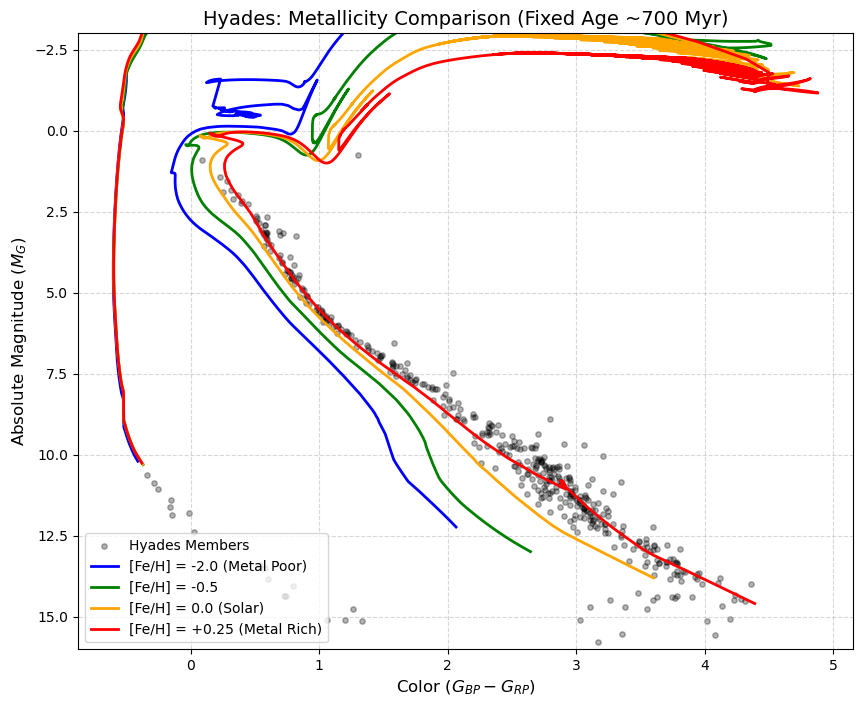

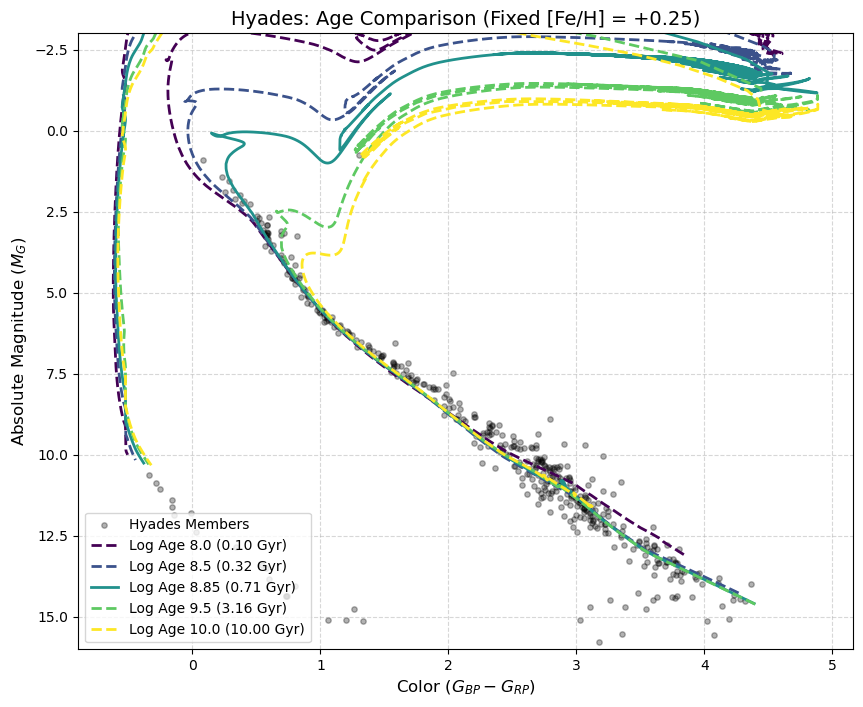

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# --- 0. PREPARE THE DATA (Re-run from your snippet) ---
distance_pc = 1000.0 / hyades_members['parallax']
abs_mag_g = hyades_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = hyades_members['bp_rp']

# --- HELPER FUNCTION TO PLOT A SINGLE ISOCHRONE LINE ---
def plot_single_iso(ax, iso_dict, log_age, color_code, label_text, linestyle='-'):
    """Helper to extract and plot a single age line from a metallicity dictionary"""
    # MIST dictionaries are usually keyed by [Fe/H] then [log_age]
    # We assume the dictionary passed IS the specific metallicity dictionary (e.g. iso_metallicity_0)
    # However, your previous read function might return {0.0: {8.0: data, ...}}
    # So we get the first (and likely only) key to access the ages.
    
    feh_key = list(iso_dict.keys())[0] # Get the metallicity float key (e.g. 0.25)
    
    # Find closest available age in this file
    avail_ages = np.array(list(iso_dict[feh_key].keys()))
    closest_age = avail_ages[np.abs(avail_ages - log_age).argmin()]
    
    data = iso_dict[feh_key][closest_age]
    
    # Try common column names
    try:
        G = data['Gaia_G_EDR3']
        BP = data['Gaia_BP_EDR3']
        RP = data['Gaia_RP_EDR3']
    except KeyError:
        # Fallback if names differ
        cols = data.columns
        G = data[[c for c in cols if 'Gaia_G' in c][0]]
        BP = data[[c for c in cols if 'Gaia_BP' in c][0]]
        RP = data[[c for c in cols if 'Gaia_RP' in c][0]]
        
    ax.plot(BP-RP, G, color=color_code, label=label_text, lw=2, linestyle=linestyle)


# ==========================================
# PLOT 1: VARYING METALLICITY (Fixed Age)
# ==========================================
# Hyades is ~700 Myr old (Log Age ~8.85). We fix this to compare metallicities.
fixed_log_age = 8.85 

fig, ax1 = plt.subplots(figsize=(10, 8))

# 1. Plot Data
ax1.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='Hyades Members')

# 2. Overplot Isochrones (Different [Fe/H])
# We manually call our helper for each of your loaded variables
plot_single_iso(ax1, iso_metallicity_neg_2,   fixed_log_age, 'blue',   '[Fe/H] = -2.0 (Metal Poor)')
plot_single_iso(ax1, iso_metallicity_neg_pt5, fixed_log_age, 'green',  '[Fe/H] = -0.5')
plot_single_iso(ax1, iso_metallicity_0,       fixed_log_age, 'orange', '[Fe/H] = 0.0 (Solar)')
plot_single_iso(ax1, iso_metallicity_pt25,    fixed_log_age, 'red',    '[Fe/H] = +0.25 (Metal Rich)')

# 3. Format
ax1.invert_yaxis()
ax1.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax1.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax1.set_title(f'Hyades: Metallicity Comparison (Fixed Age ~700 Myr)', fontsize=14)
ax1.legend(loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(16, -3) # Set limits to keep view focused

plt.show()


# ==========================================
# PLOT 2: VARYING AGE (Fixed Metallicity)
# ==========================================
# Hyades is Metal-Rich, so we use your +0.25 file as the baseline
base_iso = iso_metallicity_pt25 

fig, ax2 = plt.subplots(figsize=(10, 8))

# 1. Plot Data
ax2.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='Hyades Members')

# 2. Overplot Isochrones (Different Ages)
# Range: 100 Myr (8.0) to 15 Gyr (10.17)
age_list = [8.0, 8.5, 8.85, 9.5, 10.0] 
colors = plt.cm.viridis(np.linspace(0, 1, len(age_list))) # Generate gradient colors

for log_age, c in zip(age_list, colors):
    age_gyr = (10**log_age) / 1e9
    label_str = f'Log Age {log_age} ({age_gyr:.2f} Gyr)'
    
    # Make the "Best Fit" (8.85) stand out with a thicker line
    lw = 3 if log_age == 8.85 else 1.5
    ls = '-' if log_age == 8.85 else '--'
    
    plot_single_iso(ax2, base_iso, log_age, c, label_str, linestyle=ls)

# 3. Format
ax2.invert_yaxis()
ax2.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax2.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax2.set_title('Hyades: Age Comparison (Fixed [Fe/H] = +0.25)', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(16, -3)

plt.show()

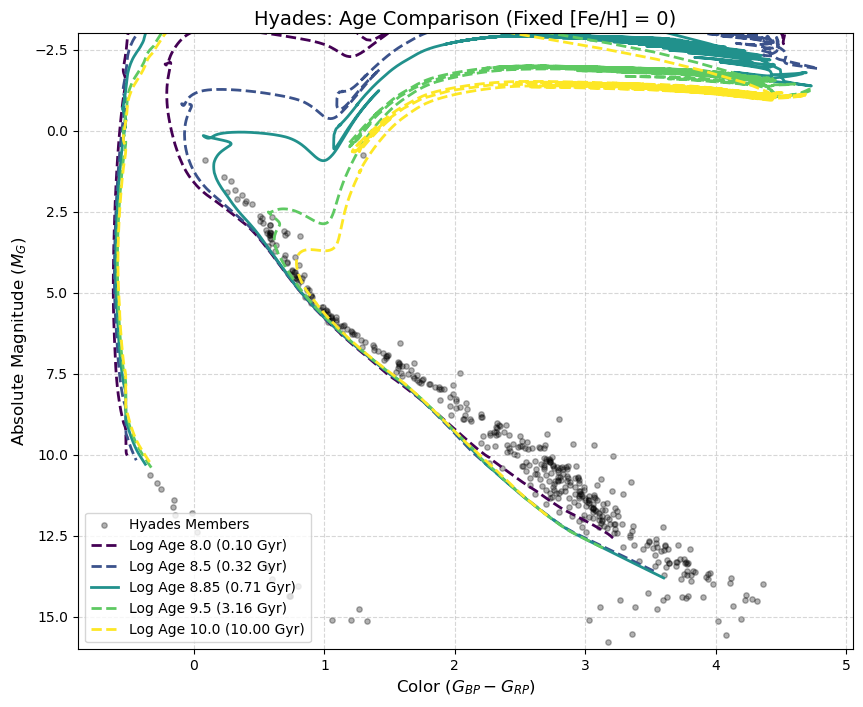

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# --- 0. PREPARE THE DATA (Re-run from your snippet) ---
distance_pc = 1000.0 / hyades_members['parallax']
abs_mag_g = hyades_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = hyades_members['bp_rp']

# --- HELPER FUNCTION TO PLOT A SINGLE ISOCHRONE LINE ---
def plot_single_iso(ax, iso_dict, log_age, color_code, label_text, linestyle='-'):
    """Helper to extract and plot a single age line from a metallicity dictionary"""
    # MIST dictionaries are usually keyed by [Fe/H] then [log_age]
    # We assume the dictionary passed IS the specific metallicity dictionary (e.g. iso_metallicity_0)
    # However, your previous read function might return {0.0: {8.0: data, ...}}
    # So we get the first (and likely only) key to access the ages.
    
    feh_key = list(iso_dict.keys())[0] # Get the metallicity float key (e.g. 0.25)
    
    # Find closest available age in this file
    avail_ages = np.array(list(iso_dict[feh_key].keys()))
    closest_age = avail_ages[np.abs(avail_ages - log_age).argmin()]
    
    data = iso_dict[feh_key][closest_age]
    
    # Try common column names
    try:
        G = data['Gaia_G_EDR3']
        BP = data['Gaia_BP_EDR3']
        RP = data['Gaia_RP_EDR3']
    except KeyError:
        # Fallback if names differ
        cols = data.columns
        G = data[[c for c in cols if 'Gaia_G' in c][0]]
        BP = data[[c for c in cols if 'Gaia_BP' in c][0]]
        RP = data[[c for c in cols if 'Gaia_RP' in c][0]]
        
    ax.plot(BP-RP, G, color=color_code, label=label_text, lw=2, linestyle=linestyle)


# ==========================================
# PLOT 2: VARYING AGE (Fixed Metallicity)
# ==========================================
base_iso = iso_metallicity_0 

fig, ax2 = plt.subplots(figsize=(10, 8))

# 1. Plot Data
ax2.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='Hyades Members')

# 2. Overplot Isochrones (Different Ages)
# Range: 100 Myr (8.0) to 15 Gyr (10.17)
age_list = [8.0, 8.5, 8.85, 9.5, 10.0] 
colors = plt.cm.viridis(np.linspace(0, 1, len(age_list))) # Generate gradient colors

for log_age, c in zip(age_list, colors):
    age_gyr = (10**log_age) / 1e9
    label_str = f'Log Age {log_age} ({age_gyr:.2f} Gyr)'
    
    # Make the "Best Fit" (8.85) stand out with a thicker line
    lw = 3 if log_age == 8.85 else 1.5
    ls = '-' if log_age == 8.85 else '--'
    
    plot_single_iso(ax2, base_iso, log_age, c, label_str, linestyle=ls)

# 3. Format
ax2.invert_yaxis()
ax2.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax2.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax2.set_title('Hyades: Age Comparison (Fixed [Fe/H] = 0)', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(16, -3)

plt.show()

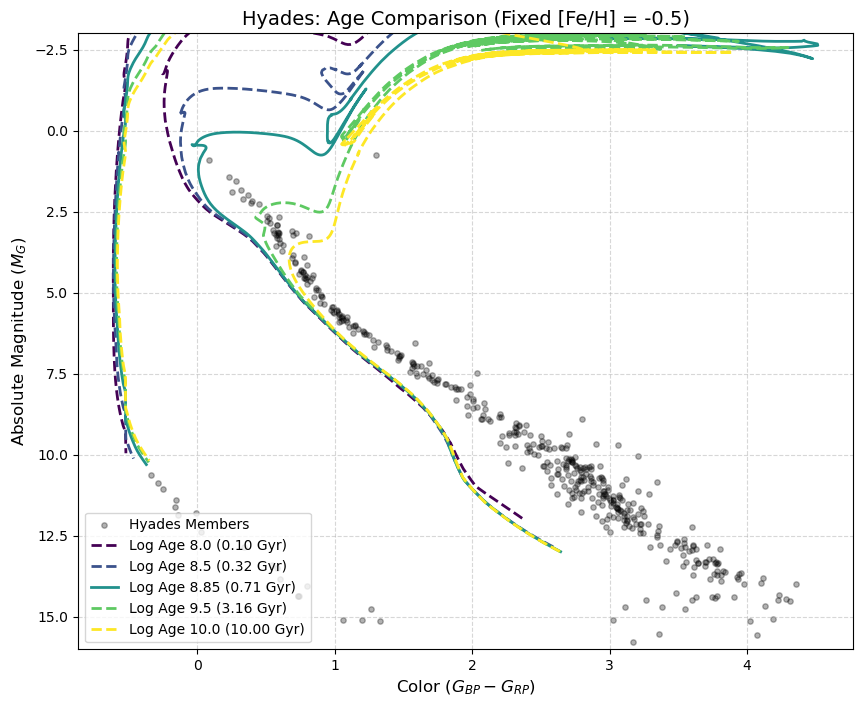

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# --- 0. PREPARE THE DATA (Re-run from your snippet) ---
distance_pc = 1000.0 / hyades_members['parallax']
abs_mag_g = hyades_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = hyades_members['bp_rp']

# --- HELPER FUNCTION TO PLOT A SINGLE ISOCHRONE LINE ---
def plot_single_iso(ax, iso_dict, log_age, color_code, label_text, linestyle='-'):
    """Helper to extract and plot a single age line from a metallicity dictionary"""
    # MIST dictionaries are usually keyed by [Fe/H] then [log_age]
    # We assume the dictionary passed IS the specific metallicity dictionary (e.g. iso_metallicity_0)
    # However, your previous read function might return {0.0: {8.0: data, ...}}
    # So we get the first (and likely only) key to access the ages.
    
    feh_key = list(iso_dict.keys())[0] # Get the metallicity float key (e.g. 0.25)
    
    # Find closest available age in this file
    avail_ages = np.array(list(iso_dict[feh_key].keys()))
    closest_age = avail_ages[np.abs(avail_ages - log_age).argmin()]
    
    data = iso_dict[feh_key][closest_age]
    
    # Try common column names
    try:
        G = data['Gaia_G_EDR3']
        BP = data['Gaia_BP_EDR3']
        RP = data['Gaia_RP_EDR3']
    except KeyError:
        # Fallback if names differ
        cols = data.columns
        G = data[[c for c in cols if 'Gaia_G' in c][0]]
        BP = data[[c for c in cols if 'Gaia_BP' in c][0]]
        RP = data[[c for c in cols if 'Gaia_RP' in c][0]]
        
    ax.plot(BP-RP, G, color=color_code, label=label_text, lw=2, linestyle=linestyle)


# ==========================================
# PLOT 2: VARYING AGE (Fixed Metallicity)
# ==========================================
base_iso = iso_metallicity_neg_pt5 

fig, ax2 = plt.subplots(figsize=(10, 8))

# 1. Plot Data
ax2.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='Hyades Members')

# 2. Overplot Isochrones (Different Ages)
# Range: 100 Myr (8.0) to 15 Gyr (10.17)
age_list = [8.0, 8.5, 8.85, 9.5, 10.0] 
colors = plt.cm.viridis(np.linspace(0, 1, len(age_list))) # Generate gradient colors

for log_age, c in zip(age_list, colors):
    age_gyr = (10**log_age) / 1e9
    label_str = f'Log Age {log_age} ({age_gyr:.2f} Gyr)'
    
    # Make the "Best Fit" (8.85) stand out with a thicker line
    lw = 3 if log_age == 8.85 else 1.5
    ls = '-' if log_age == 8.85 else '--'
    
    plot_single_iso(ax2, base_iso, log_age, c, label_str, linestyle=ls)

# 3. Format
ax2.invert_yaxis()
ax2.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax2.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax2.set_title('Hyades: Age Comparison (Fixed [Fe/H] = -0.5)', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(16, -3)

plt.show()